In [1]:
from Bio.PDB import PDBParser, PDBList, MMCIFParser
from Bio.SeqIO.FastaIO import SimpleFastaParser
import sys
import os
pdbl = PDBList()
parser = MMCIFParser(QUIET=True)

In [2]:
pdb_id = "1CRN"  #
pdb_list = PDBList()
# Download mmCIF structure file from the RCSB PDB
cif_file = pdb_list.retrieve_pdb_file(pdb_id, pdir="1crn_test", file_format="mmCif")
# Parse the mmCIF file
structure = parser.get_structure(pdb_id, cif_file)
print(f"Successfully parsed structure: {structure.id}")
# Print the number of models, chains, residues, and atoms in the structure
print(
    f"Structure ID: {structure.id}"
    f"\nNumber of models: {len(list(structure))}"
    f"\nNumber of chains: {len(list(structure.get_chains()))}"
    f"\nNumber of residues: {len(list(structure.get_residues()))}"
    f"\nNumber of atoms: {len(list(structure.get_atoms()))}"
)

Structure exists: '1crn_test\1crn.cif' 
Successfully parsed structure: 1CRN
Structure ID: 1CRN
Number of models: 1
Number of chains: 1
Number of residues: 46
Number of atoms: 327


In [4]:
coords = []
for atom in structure.get_atoms():
    if atom.name == "CA":  # Only consider alpha carbon atoms
        coords.append(atom.coord)
print(f"Number of alpha carbon atoms: {len(coords)}")
import numpy as np
coords_array = np.array(coords)
print(f"Shape of coordinates array: {coords_array.shape}")


Number of alpha carbon atoms: 46
Shape of coordinates array: (46, 3)


In [5]:
from scipy.spatial.distance import pdist, squareform, cdist
# Compute the pairwise distance matrix for the alpha carbon atoms
distance_matrix = cdist(coords_array, coords_array)
#Print the first 5 rows and columns of the distance matrix
print("Pairwise distance matrix (first 5 rows and columns):")
print(distance_matrix[:5, :5])

Pairwise distance matrix (first 5 rows and columns):
[[ 0.          3.79388013  6.70386269 10.21404833 13.58426034]
 [ 3.79388013  0.          3.80327478  6.70682837 10.2659926 ]
 [ 6.70386269  3.80327478  0.          3.82837984  6.91668266]
 [10.21404833  6.70682837  3.82837984  0.          3.79814028]
 [13.58426034 10.2659926   6.91668266  3.79814028  0.        ]]


In [6]:
# Create a fake distance matrix by adding random noise to the original coordinates and recomputing the distance matrix
noisy_distance_matrix = coords_array + np.random.normal(0, 2.0, coords_array.shape)
fake_distance_matrix = cdist(noisy_distance_matrix, noisy_distance_matrix)
diff_matrix = np.abs(distance_matrix - fake_distance_matrix)

print(f'First 5 rows and columns of the true distance matrix: {distance_matrix[:5, :5]}')
print(f'First 5 rows and columns of the fake distance matrix: {fake_distance_matrix[:5, :5]}')

First 5 rows and columns of the true distance matrix: [[ 0.          3.79388013  6.70386269 10.21404833 13.58426034]
 [ 3.79388013  0.          3.80327478  6.70682837 10.2659926 ]
 [ 6.70386269  3.80327478  0.          3.82837984  6.91668266]
 [10.21404833  6.70682837  3.82837984  0.          3.79814028]
 [13.58426034 10.2659926   6.91668266  3.79814028  0.        ]]
First 5 rows and columns of the fake distance matrix: [[ 0.          2.92523454 10.40395171 12.66133468 15.81639289]
 [ 2.92523454  0.          8.15451302  9.88393418 13.71207221]
 [10.40395171  8.15451302  0.          4.71147797  5.58906699]
 [12.66133468  9.88393418  4.71147797  0.          7.07921384]
 [15.81639289 13.71207221  5.58906699  7.07921384  0.        ]]


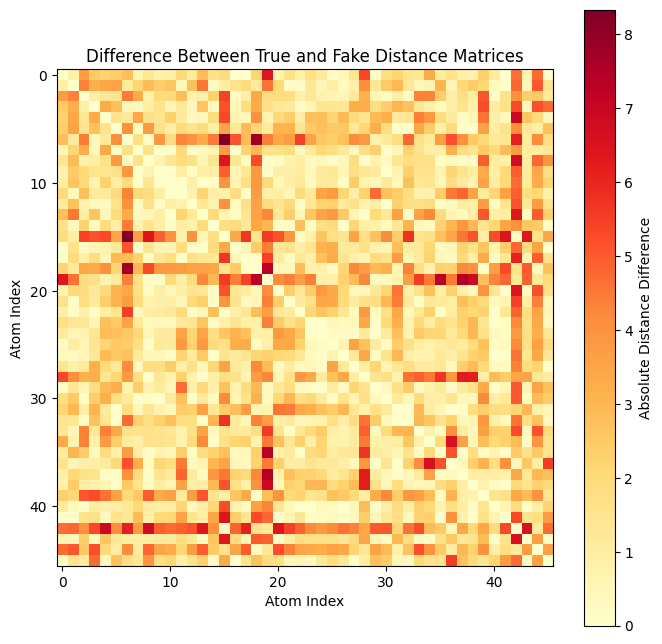

In [7]:
# Visualise the difference between the true and fake distance matrices
diff_matrix = np.abs(distance_matrix - fake_distance_matrix)
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.imshow(diff_matrix, cmap='YlOrRd')
plt.colorbar(label='Absolute Distance Difference')
plt.title('Difference Between True and Fake Distance Matrices')
plt.xlabel('Atom Index')
plt.ylabel('Atom Index')
plt.show()

In [8]:
#Get the ID so we can retrieve the Alphafold structure for the same PDB ID
header = structure.header
#Print the common name of the protein
print(f"Protein name: {header['name']}")



Protein name: WATER STRUCTURE OF A HYDROPHOBIC PROTEIN AT ATOMIC RESOLUTION. PENTAGON RINGS OF WATER MOLECULES IN CRYSTALS OF CRAMBIN


In [9]:
alphafold_cif_file = 'AF-P01542-F1-model_v6.cif'
#Get the distance matrix for the Alphafold structure
structure_af = parser.get_structure(pdb_id + "_AF", alphafold_cif_file)
print(f"Successfully parsed AlphaFold structure: {structure_af.id}")
print(f"AlphaFold Structure ID: {structure_af.id}")
print(f"Number of models in AlphaFold structure: {len(list(structure_af))}")
print(f"Number of chains in AlphaFold structure: {len(list(structure_af.get_chains()))}")
print(f"Number of residues in AlphaFold structure: {len(list(structure_af.get_residues()))}")
print(f"Number of atoms in AlphaFold structure: {len(list(structure_af.get_atoms()))}")

Successfully parsed AlphaFold structure: 1CRN_AF
AlphaFold Structure ID: 1CRN_AF
Number of models in AlphaFold structure: 1
Number of chains in AlphaFold structure: 1
Number of residues in AlphaFold structure: 46
Number of atoms in AlphaFold structure: 327


In [10]:
#Distance matrix for the Alphafold structure
coords_af = []
for atom in structure_af.get_atoms():
    if atom.name == "CA":  # Only consider alpha carbon atoms
        coords_af.append(atom.coord)
coords_af_array = np.array(coords_af)
distance_matrix_af = cdist(coords_af_array, coords_af_array)
#Print the first 5 rows and columns of the Alphafold distance matrix
print("AlphaFold pairwise distance matrix (first 5 rows and columns):")
print(distance_matrix_af[:5, :5])

AlphaFold pairwise distance matrix (first 5 rows and columns):
[[ 0.          3.82690708  6.47496925 10.08085652 13.45316428]
 [ 3.82690708  0.          3.8423639   6.75384807 10.39188295]
 [ 6.47496925  3.8423639   0.          3.84194758  6.98345276]
 [10.08085652  6.75384807  3.84194758  0.          3.85488646]
 [13.45316428 10.39188295  6.98345276  3.85488646  0.        ]]


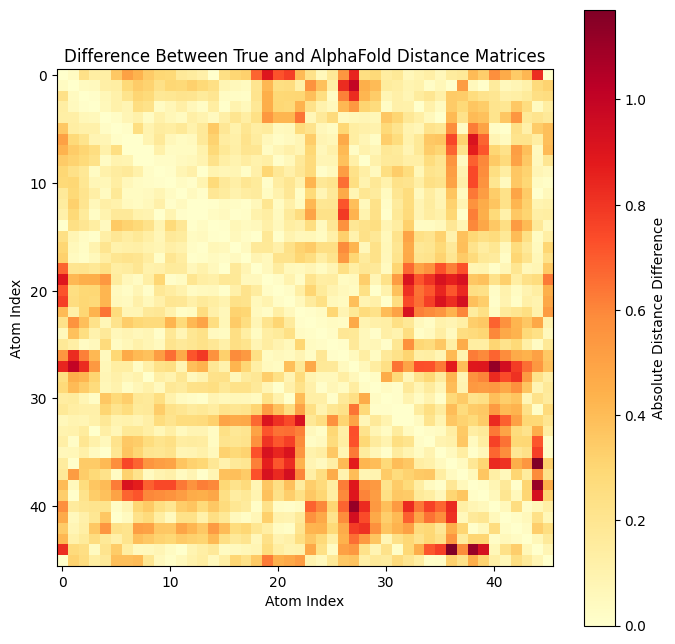

In [10]:
diff_matrix = np.abs(distance_matrix - distance_matrix_af)
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.imshow(diff_matrix, cmap='YlOrRd')
plt.colorbar(label='Absolute Distance Difference')
plt.title('Difference Between True and AlphaFold Distance Matrices')
plt.xlabel('Atom Index')
plt.ylabel('Atom Index')
plt.show()

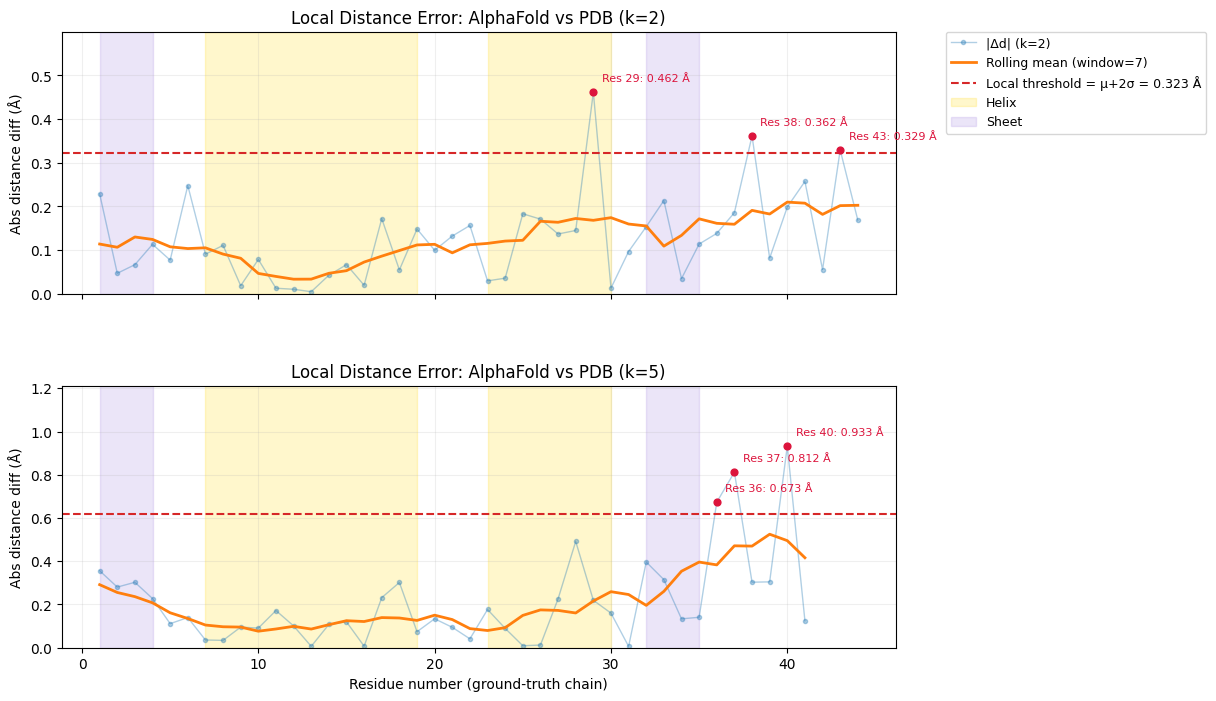

In [30]:
# Diagonal extraction (k=2 and k=5) + secondary-structure annotation + rolling mean + local thresholds
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

k_values = [2, 5]
rolling_window = 7
annotate_top_n = 3

# Build residue-number x-axis from the ground-truth structure (CA residues only).
model = next(structure.get_models())
chain = next(model.get_chains())
chain_id = chain.id
residue_numbers = [
    res.get_id()[1]
    for res in chain
    if res.id[0] == ' ' and 'CA' in res
]

def _as_list(val):
    if val is None:
        return []
    return val if isinstance(val, list) else [val]

def extract_secstruct_spans_from_cif(cif_path, target_chain_id):
    d = MMCIF2Dict(cif_path)
    helices, sheets = [], []

    # Helices from struct_conf
    helix_beg = _as_list(d.get('_struct_conf.beg_auth_seq_id'))
    helix_end = _as_list(d.get('_struct_conf.end_auth_seq_id'))
    helix_chain = _as_list(d.get('_struct_conf.beg_auth_asym_id'))
    helix_type = _as_list(d.get('_struct_conf.conf_type_id'))

    for beg, end, ch, conf in zip(helix_beg, helix_end, helix_chain, helix_type):
        if str(ch) == str(target_chain_id) and 'HELX' in str(conf).upper():
            helices.append((int(beg), int(end)))

    # Sheets from struct_sheet_range
    sheet_beg = _as_list(d.get('_struct_sheet_range.beg_auth_seq_id'))
    sheet_end = _as_list(d.get('_struct_sheet_range.end_auth_seq_id'))
    sheet_chain = _as_list(d.get('_struct_sheet_range.beg_auth_asym_id'))

    for beg, end, ch in zip(sheet_beg, sheet_end, sheet_chain):
        if str(ch) == str(target_chain_id):
            sheets.append((int(beg), int(end)))

    return helices, sheets

helices, sheets = extract_secstruct_spans_from_cif(cif_file, chain_id)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

for idx, (ax, diag_k) in enumerate(zip(axes, k_values)):
    diagonal_diff = np.diag(diff_matrix, k=diag_k)
    x_res = np.array(residue_numbers[:len(diagonal_diff)])

    rolling_mean = pd.Series(diagonal_diff).rolling(
        window=rolling_window, center=True, min_periods=1
    ).mean().to_numpy()

    # Local threshold: mean + 2*std
    local_threshold = float(np.mean(diagonal_diff) + 2 * np.std(diagonal_diff))

    # Dynamic y-scale to avoid empty headroom
    max_val = float(np.max(diagonal_diff)) if len(diagonal_diff) else 0.0
    y_upper = max(0.08, max_val * 1.30)

    ax.plot(
        x_res, diagonal_diff, color='tab:blue', alpha=0.35, marker='o', markersize=3, linewidth=1,
        label=f'|Δd| (k={diag_k})'
    )
    ax.plot(
        x_res, rolling_mean, color='tab:orange', linewidth=2,
        label=f'Rolling mean (window={rolling_window})'
    )
    ax.axhline(
        local_threshold, color='tab:red', linestyle='--', linewidth=1.5,
        label=f'Local threshold = μ+2σ = {local_threshold:.3f} Å'
    )

    # Shade helices and sheets
    first_h, first_s = True, True
    for start, end in helices:
        ax.axvspan(start, end, color='gold', alpha=0.20, label='Helix' if first_h else None)
        first_h = False
    for start, end in sheets:
        ax.axvspan(start, end, color='mediumpurple', alpha=0.18, label='Sheet' if first_s else None)
        first_s = False

    # Annotate worst residues (largest absolute differences)
    if len(diagonal_diff) > 0:
        top_n = min(annotate_top_n, len(diagonal_diff))
        worst_idx = np.argsort(diagonal_diff)[-top_n:]
        x_max = np.max(x_res)
        for wi in worst_idx:
            xw = x_res[wi]
            yw = diagonal_diff[wi]
            ax.scatter([xw], [yw], color='crimson', s=24, zorder=4)

            is_near_top = yw > (0.88 * y_upper)
            is_near_right = xw > (x_max - 1)
            if is_near_top or is_near_right:
                xytext = (-6, -8)
                ha, va = 'right', 'top'
            else:
                xytext = (6, 6)
                ha, va = 'left', 'bottom'

            ax.annotate(
                f'Res {xw}: {yw:.3f} Å',
                xy=(xw, yw),
                xytext=xytext,
                textcoords='offset points',
                fontsize=8,
                color='crimson',
                ha=ha,
                va=va,
                annotation_clip=False
            )

    ax.set_ylim(0, y_upper)
    ax.set_ylabel('Abs distance diff (Å)')
    ax.set_title(f'Local Distance Error: AlphaFold vs PDB (k={diag_k})')
    ax.grid(alpha=0.2)

    # Keep legend only on first panel to reduce clutter
    if idx == 0:
        ax.legend( fontsize=9,bbox_to_anchor=(1.06, 1), borderaxespad=0)
        ax.tick_params(axis='x', which='both', labelbottom=False)

axes[-1].set_xlabel('Residue number (ground-truth chain)')
plt.subplots_adjust(hspace=0.35,right=0.82)
plt.show()

## Mostly EDA

In [18]:
# Summary findings table for k-diagonal error profiles
import numpy as np
import pandas as pd
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
from IPython.display import display

k_values_summary = [2, 5]
top_n_per_k = 5

# Rebuild CA residue numbering (ground-truth chain)
model = next(structure.get_models())
chain = next(model.get_chains())
chain_id = chain.id
residue_numbers = [
    res.get_id()[1]
    for res in chain
    if res.id[0] == ' ' and 'CA' in res
]

def _as_list(val):
    if val is None:
        return []
    return val if isinstance(val, list) else [val]

def extract_secstruct_spans_from_cif(cif_path, target_chain_id):
    d = MMCIF2Dict(cif_path)
    helices, sheets = [], []

    helix_beg = _as_list(d.get('_struct_conf.beg_auth_seq_id'))
    helix_end = _as_list(d.get('_struct_conf.end_auth_seq_id'))
    helix_chain = _as_list(d.get('_struct_conf.beg_auth_asym_id'))
    helix_type = _as_list(d.get('_struct_conf.conf_type_id'))
    for beg, end, ch, conf in zip(helix_beg, helix_end, helix_chain, helix_type):
        if str(ch) == str(target_chain_id) and 'HELX' in str(conf).upper():
            helices.append((int(beg), int(end)))

    sheet_beg = _as_list(d.get('_struct_sheet_range.beg_auth_seq_id'))
    sheet_end = _as_list(d.get('_struct_sheet_range.end_auth_seq_id'))
    sheet_chain = _as_list(d.get('_struct_sheet_range.beg_auth_asym_id'))
    for beg, end, ch in zip(sheet_beg, sheet_end, sheet_chain):
        if str(ch) == str(target_chain_id):
            sheets.append((int(beg), int(end)))

    return helices, sheets

helices, sheets = extract_secstruct_spans_from_cif(cif_file, chain_id)

def secstruct_label(resnum, helices, sheets):
    for start, end in helices:
        if start <= resnum <= end:
            return 'Helix'
    for start, end in sheets:
        if start <= resnum <= end:
            return 'Sheet'
    return 'Loop/Other'

overall_rows = []
hotspot_rows = []

for k in k_values_summary:
    diag = np.diag(diff_matrix, k=k)
    x_res = np.array(residue_numbers[:len(diag)])

    if len(diag) == 0:
        continue

    mu = float(np.mean(diag))
    sigma = float(np.std(diag))
    threshold = mu + 2 * sigma

    max_idx = int(np.argmax(diag))
    max_res = int(x_res[max_idx])
    max_val = float(diag[max_idx])

    above_mask = diag > threshold
    n_above = int(np.sum(above_mask))
    pct_above = float(100 * n_above / len(diag))

    overall_rows.append({
        'k': k,
        'n_pairs': int(len(diag)),
        'mean_abs_diff_A': round(mu, 4),
        'std_A': round(sigma, 4),
        'mu_plus_2sigma_A': round(threshold, 4),
        'max_abs_diff_A': round(max_val, 4),
        'max_residue': max_res,
        'n_above_threshold': n_above,
        'pct_above_threshold': round(pct_above, 2),
    })

    top_n = min(top_n_per_k, len(diag))
    top_idx = np.argsort(diag)[-top_n:][::-1]
    for rank, i in enumerate(top_idx, start=1):
        val = float(diag[i])
        zscore = (val - mu) / sigma if sigma > 1e-12 else np.nan
        res = int(x_res[i])
        hotspot_rows.append({
            'k': k,
            'rank': rank,
            'residue': res,
            'abs_diff_A': round(val, 4),
            'z_score': round(float(zscore), 3) if np.isfinite(zscore) else np.nan,
            'above_mu_plus_2sigma': bool(val > threshold),
            'secondary_structure': secstruct_label(res, helices, sheets),
        })

overall_df = pd.DataFrame(overall_rows).sort_values('k').reset_index(drop=True)
hotspot_df = pd.DataFrame(hotspot_rows).sort_values(['k', 'rank']).reset_index(drop=True)

print('Overall findings by diagonal offset')
display(overall_df)

print('\nTop hotspot residues per k')
display(hotspot_df)

Overall findings by diagonal offset


,k,n_pairs,mean_abs_diff_A,std_A,mu_plus_2sigma_A,max_abs_diff_A,max_residue,n_above_threshold,pct_above_threshold
0,2,44,0.1265,0.0981,0.3227,0.4615,29,3,6.82
1,5,41,0.2095,0.2053,0.6200,0.9327,40,3,7.32



Top hotspot residues per k


,k,rank,residue,abs_diff_A,z_score,above_mu_plus_2sigma,secondary_structure
0,2,1,29,0.4615,3.416,True,Helix
1,2,2,38,0.3617,2.398,True,Loop/Other
2,2,3,43,0.3294,2.068,True,Loop/Other
3,2,4,41,0.2573,1.333,False,Loop/Other
4,2,5,6,0.2478,1.237,False,Loop/Other
5,5,1,40,0.9327,3.523,True,Loop/Other
6,5,2,37,0.8118,2.935,True,Loop/Other
7,5,3,36,0.6732,2.259,True,Loop/Other
8,5,4,28,0.4917,1.375,False,Helix
9,5,5,32,0.3964,0.910,False,Sheet


In [51]:
clashes = np.where((diff_matrix < 2.0)  & (diff_matrix > 0.0))
if len(clashes[0]) > 0:
    print(f'Warning - found {len(clashes[0])//2} potential clashes (distance differences < 2.0 Å) between the true structure and the AlphaFold prediction.')
else:
    print('No significant clashes found between the true structure and the AlphaFold prediction.')

Warning - found 1035 potential clashes (distance differences < 2.0 Å) between the true structure and the AlphaFold prediction.


In [56]:
bonds = np.diag(distance_matrix_af, k=4)
outliers = np.where((bonds < 3.0) | (bonds > 4.0))

print(f'Number of potential bond outliers (CA-CA distances < 3.0 Å or > 4.0 Å) in the AlphaFold structure: {len(outliers)}')
print(f'Average bond length (CA-CA) in the AlphaFold structure: {np.mean(bonds):.2f} Å')

Number of potential bond outliers (CA-CA distances < 3.0 Å or > 4.0 Å) in the AlphaFold structure: 1
Average bond length (CA-CA) in the AlphaFold structure: 8.43 Å


## Use py3DMol to Visualise the protein.

In [6]:
import py3Dmol
from io import StringIO
from Bio.PDB import MMCIFIO

# Create an in-memory text buffer to hold the mmCIF output
sio = StringIO()

# Create a Biopython mmCIF writer and load the structure into it
io_object = MMCIFIO()
io_object.set_structure(structure)

# Write the structure into the text buffer
io_object.save(sio)
cif_string = sio.getvalue()

# Display the structure in 3D
view = py3Dmol.view(width=400, height=400)
view.addModel(cif_string, 'cif')
view.setStyle({'cartoon': {'color': 'spectrum'}})
view.zoomTo()
view

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [44]:
import py3Dmol
from pathlib import Path

# 1CRN is the PDB ID
# P01542 is the matching UniProt ID for AlphaFold

left_cif = Path("cif_test/1crn.cif").read_text()
right_cif = Path("cif_test/AF-P01542-F1-model_v6.cif").read_text()

view = py3Dmol.view(viewergrid=(1, 2), width=1000, height=520)

# 1) Left side: experimental structure
view.addModel(left_cif, 'cif', viewer=(0, 0))
view.setStyle({'cartoon': {'color': 'blue', 'thickness': 1.0}}, viewer=(0, 0))
view.zoomTo(viewer=(0, 0))

# 2) Right side: AlphaFold prediction
view.addModel(right_cif, 'cif', viewer=(0, 1))
view.setStyle({'cartoon': {'color': 'orange', 'thickness': 1.0}}, viewer=(0, 1))
view.zoomTo(viewer=(0, 1))

view.setBackgroundColor('white', viewer=(0, 0))
view.setBackgroundColor('white', viewer=(0, 1))
view.spin('y', 0.2)
view.spin('x', 0.2)
view.show()



3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Protein Evaluator Class

In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from Bio.PDB import PDBList, MMCIFParser, Superimposer
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
from IPython.display import display
import plotly.graph_objects as go
from plotly.subplots import make_subplots

class ProteinEvaluator:
    """Pipeline to compare experimental PDB and AlphaFold structures."""

    def __init__(self, pdb_id, alphafold_cif_file='AF-P01542-F1-model_v6.cif', work_dir='1crn_test'):
        self.pdb_id = pdb_id.upper()
        self.alphafold_cif_file = alphafold_cif_file
        self.work_dir = work_dir

        self.parser = MMCIFParser(QUIET=True)
        self.pdb_list = PDBList()

        self.pdb_cif_file = None
        self.structure = None
        self.structure_af = None

        self.pdb_coords = None
        self.af_coords = None
        self.af_plddt = []
        self.residue_numbers = []
        self.chain_id = None
        self.superimposer_rms = None

        self.distance_matrix = None
        self.distance_matrix_af = None
        self.cross_distance_matrix = None
        self.diff_matrix = None

        self.helices = []
        self.sheets = []

        self.overall_df = pd.DataFrame()
        self.hotspot_df = pd.DataFrame()
        self.residue_profile_df = pd.DataFrame()

    def _as_list(self, val):
        if val is None:
            return []
        return val if isinstance(val, list) else [val]

    def _extract_secstruct_spans_from_cif(self, cif_path, target_chain_id):
        d = MMCIF2Dict(cif_path)
        helices, sheets = [], []

        helix_beg = self._as_list(d.get('_struct_conf.beg_auth_seq_id'))
        helix_end = self._as_list(d.get('_struct_conf.end_auth_seq_id'))
        helix_chain = self._as_list(d.get('_struct_conf.beg_auth_asym_id'))
        helix_type = self._as_list(d.get('_struct_conf.conf_type_id'))
        for beg, end, ch, conf in zip(helix_beg, helix_end, helix_chain, helix_type):
            if str(ch) == str(target_chain_id) and 'HELX' in str(conf).upper():
                helices.append((int(beg), int(end)))

        sheet_beg = self._as_list(d.get('_struct_sheet_range.beg_auth_seq_id'))
        sheet_end = self._as_list(d.get('_struct_sheet_range.end_auth_seq_id'))
        sheet_chain = self._as_list(d.get('_struct_sheet_range.beg_auth_asym_id'))
        for beg, end, ch in zip(sheet_beg, sheet_end, sheet_chain):
            if str(ch) == str(target_chain_id):
                sheets.append((int(beg), int(end)))

        return helices, sheets

    def _secstruct_label(self, resnum):
        for start, end in self.helices:
            if start <= resnum <= end:
                return 'Helix'
        for start, end in self.sheets:
            if start <= resnum <= end:
                return 'Sheet'
        return 'Loop/Other'

    def fetch_structures(self):
        self.pdb_cif_file = self.pdb_list.retrieve_pdb_file(
            self.pdb_id, pdir=self.work_dir, file_format='mmCif'
        )
        self.structure = self.parser.get_structure(self.pdb_id, self.pdb_cif_file)

        af_path = Path(self.alphafold_cif_file)
        if not af_path.exists():
            raise FileNotFoundError(
                f'AlphaFold CIF not found: {self.alphafold_cif_file}. Put the file in the workspace or pass a valid path.'
            )
        self.structure_af = self.parser.get_structure(f'{self.pdb_id}_AF', str(af_path))

        print(f'Loaded PDB structure: {self.structure.id}')
        print(f'Loaded AlphaFold structure: {self.structure_af.id}')

    def parse_and_align_structures(self):
        if self.structure is None or self.structure_af is None:
            raise RuntimeError('Run fetch_structures() before parse_and_align_structures().')

        pdb_model = next(self.structure.get_models())
        pdb_chain = next(pdb_model.get_chains())
        self.chain_id = pdb_chain.id

        pdb_ca_atoms = []
        residue_numbers = []
        for res in pdb_chain:
            if res.id[0] == ' ' and 'CA' in res:
                pdb_ca_atoms.append(res['CA'])
                residue_numbers.append(res.get_id()[1])

        af_model = next(self.structure_af.get_models())
        af_chain = next(af_model.get_chains())
        af_ca_atoms = []
        af_plddt = []
        for res in af_chain:
            if res.id[0] == ' ' and 'CA' in res:
                af_ca_atoms.append(res['CA'])
                af_plddt.append(float(res['CA'].get_bfactor()))

        n = min(len(pdb_ca_atoms), len(af_ca_atoms))
        if n == 0:
            raise ValueError('No Cα atoms found for comparison.')

        # Superimpose AlphaFold onto the experimental structure using matched Cα atoms.
        sup = Superimposer()
        sup.set_atoms(pdb_ca_atoms[:n], af_ca_atoms[:n])
        sup.apply(self.structure_af.get_atoms())
        self.superimposer_rms = float(sup.rms)

        self.pdb_coords = np.array([atom.coord for atom in pdb_ca_atoms[:n]])
        self.af_coords = np.array([atom.coord for atom in af_ca_atoms[:n]])
        self.af_plddt = af_plddt[:n]
        self.residue_numbers = residue_numbers[:n]

        self.helices, self.sheets = self._extract_secstruct_spans_from_cif(
            self.pdb_cif_file, self.chain_id
        )

        print(f'Using {n} matched Cα atoms for comparison.')
        print(f'Chain used: {self.chain_id}')
        print(f'Cα superposition RMSD: {self.superimposer_rms:.3f} Å')

    def compute_invariants(self, k_values=(2, 5), top_n_per_k=5):
        if self.pdb_coords is None or self.af_coords is None:
            raise RuntimeError('Run parse_and_align_structures() before compute_invariants().')

        self.distance_matrix = cdist(self.pdb_coords, self.pdb_coords)
        self.distance_matrix_af = cdist(self.af_coords, self.af_coords)
        self.cross_distance_matrix = cdist(self.pdb_coords, self.af_coords)
        self.diff_matrix = np.abs(self.distance_matrix - self.distance_matrix_af)

        overall_rows = []
        hotspot_rows = []
        profile_rows = []

        for k in k_values:
            diag = np.diag(self.diff_matrix, k=k)
            x_res = np.array(self.residue_numbers[:len(diag)])
            if len(diag) == 0:
                continue

            mu = float(np.mean(diag))
            sigma = float(np.std(diag))
            threshold = mu + 2 * sigma

            max_idx = int(np.argmax(diag))
            max_res = int(x_res[max_idx])
            max_val = float(diag[max_idx])

            n_above = int(np.sum(diag > threshold))
            pct_above = float(100 * n_above / len(diag))

            overall_rows.append({
                'k': int(k),
                'n_pairs': int(len(diag)),
                'mean_abs_diff_A': round(mu, 4),
                'std_A': round(sigma, 4),
                'mu_plus_2sigma_A': round(threshold, 4),
                'max_abs_diff_A': round(max_val, 4),
                'max_residue': max_res,
                'n_above_threshold': n_above,
                'pct_above_threshold': round(pct_above, 2),
            })

            for i, val in enumerate(diag):
                res = int(x_res[i])
                zscore = (float(val) - mu) / sigma if sigma > 1e-12 else np.nan
                profile_rows.append({
                    'k': int(k),
                    'residue': res,
                    'abs_diff_A': round(float(val), 4),
                    'plddt': round(float(self.af_plddt[i]), 2) if i < len(self.af_plddt) else np.nan,
                    'z_score': round(float(zscore), 3) if np.isfinite(zscore) else np.nan,
                    'above_mu_plus_2sigma': bool(float(val) > threshold),
                    'secondary_structure': self._secstruct_label(res),
                })

            top_n = min(top_n_per_k, len(diag))
            top_idx = np.argsort(diag)[-top_n:][::-1]
            for rank, i in enumerate(top_idx, start=1):
                val = float(diag[i])
                zscore = (val - mu) / sigma if sigma > 1e-12 else np.nan
                res = int(x_res[i])
                hotspot_rows.append({
                    'k': int(k),
                    'rank': int(rank),
                    'residue': res,
                    'abs_diff_A': round(val, 4),
                    'z_score': round(float(zscore), 3) if np.isfinite(zscore) else np.nan,
                    'above_mu_plus_2sigma': bool(val > threshold),
                    'secondary_structure': self._secstruct_label(res),
                })

        self.overall_df = pd.DataFrame(overall_rows).sort_values('k').reset_index(drop=True)
        self.hotspot_df = pd.DataFrame(hotspot_rows).sort_values(['k', 'rank']).reset_index(drop=True)
        self.residue_profile_df = pd.DataFrame(profile_rows).sort_values(['k', 'residue']).reset_index(drop=True)

        print('Overall findings by diagonal offset')
        display(self.overall_df)
        print('\nTop hotspot residues per k')
        display(self.hotspot_df)

        return self.overall_df, self.hotspot_df

    def _build_toggle_cdist_heatmap(self):
        if self.distance_matrix is None or self.distance_matrix_af is None or self.cross_distance_matrix is None:
            raise RuntimeError('Run compute_invariants() before generating heatmaps.')

        matrix_options = [
            ('PDB self-distance', self.distance_matrix),
            ('AlphaFold self-distance', self.distance_matrix_af),
            ('PDB vs AlphaFold cross-distance', self.cross_distance_matrix),
        ]

        fig = go.Figure()
        n = self.distance_matrix.shape[0]
        indices = np.arange(n)
        x_grid, y_grid = np.meshgrid(indices, indices)

        for idx, (label, matrix) in enumerate(matrix_options):
            fig.add_trace(
                go.Heatmap(
                    z=matrix,
                    x=indices,
                    y=indices,
                    coloraxis='coloraxis',
                    visible=(idx == 0),
                    customdata=np.dstack((x_grid, y_grid)),
                    hovertemplate='i: %{customdata[1]}<br>j: %{customdata[0]}<br>distance: %{z:.3f} Å<extra>' + label + '</extra>'
                )
            )

        buttons = []
        for idx, (label, _) in enumerate(matrix_options):
            visibility = [False] * len(matrix_options)
            visibility[idx] = True
            buttons.append({
                'label': label,
                'method': 'update',
                'args': [
                    {'visible': visibility},
                    {'title': f'Interactive Cα Distance Heatmap: {label}'}
                ],
            })

        fig.update_layout(
            title='Interactive Cα Distance Heatmap: PDB self-distance',
            xaxis_title='Atom/Residue index',
            yaxis_title='Atom/Residue index',
            width=820,
            height=760,
            coloraxis=dict(colorscale='YlOrRd', colorbar=dict(title='Distance (Å)')),
            updatemenus=[{
                'buttons': buttons,
                'direction': 'down',
                'x': 1.02,
                'y': 1.0,
                'xanchor': 'left',
                'yanchor': 'top',
            }],
            margin=dict(l=70, r=220, t=80, b=70),
        )

        return fig

    def _build_outlier_scatter(self, k_values=(2, 5)):
        if self.residue_profile_df.empty:
            raise RuntimeError('Run compute_invariants() before generating outlier scatter.')

        data = self.residue_profile_df[self.residue_profile_df['k'].isin(k_values)].copy()
        if data.empty:
            raise ValueError(f'No residue-profile data found for k values: {k_values}')

        color_map = {'Helix': '#1f77b4', 'Sheet': '#9467bd', 'Loop/Other': '#2ca02c'}
        symbol_map = {False: 'circle', True: 'diamond'}

        fig = make_subplots(
            rows=len(k_values),
            cols=1,
            shared_xaxes=True,
            vertical_spacing=0.12,
            subplot_titles=[f'Residue Outliers (k={k})' for k in k_values],
        )

        for row_idx, k in enumerate(k_values, start=1):
            subset_k = data[data['k'] == k]
            for ss_label in ['Helix', 'Sheet', 'Loop/Other']:
                subset_ss = subset_k[subset_k['secondary_structure'] == ss_label]
                if subset_ss.empty:
                    continue
                for above in [False, True]:
                    subset = subset_ss[subset_ss['above_mu_plus_2sigma'] == above]
                    if subset.empty:
                        continue

                    fig.add_trace(
                        go.Scatter(
                            x=subset['residue'],
                            y=subset['z_score'],
                            mode='markers',
                            marker=dict(
                                color=color_map[ss_label],
                                symbol=symbol_map[above],
                                size=9 if above else 7,
                                line=dict(color='black', width=0.4),
                            ),
                            name=f"{ss_label} | {'outlier' if above else 'inlier'}",
                            legendgroup=f"{ss_label}_{above}",
                            showlegend=(row_idx == 1),
                            customdata=np.stack(
                                [
                                    subset['abs_diff_A'].values,
                                    subset['secondary_structure'].values,
                                    subset['above_mu_plus_2sigma'].values,
                                ],
                                axis=-1,
                            ),
                            hovertemplate=(
'Residue %{x}<br>'
'z-score %{y:.3f}<br>'
'abs diff %{customdata[0]:.3f} Å<br>'
'SS %{customdata[1]}<br>'
'above μ+2σ %{customdata[2]}<extra></extra>'
),
                        ),
                        row=row_idx, col=1,
                    )

            fig.add_hline(
                y=2.0,
                line_dash='dash',
                line_color='firebrick',
                annotation_text='z = 2',
                annotation_position='top right',
                row=row_idx, col=1,
            )
            fig.update_yaxes(title='z-score', row=row_idx, col=1)

        fig.update_xaxes(title='Residue number', row=len(k_values), col=1)
        fig.update_layout(
            title='Residue Outlier Scatter (color = SS, symbol = above μ+2σ)',
            height=360 * len(k_values),
            width=980,
            legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0.0),
            margin=dict(l=70, r=30, t=90, b=70),
        )

        return fig

    def _build_multik_diagonal_dropdown(self, k_values=(1, 2, 5), rolling_window=7, annotate_top_n=3):
        if self.diff_matrix is None:
            raise RuntimeError('Run compute_invariants() before generating diagonal dropdown plot.')

        fig = go.Figure()
        group_size = 4  # raw, rolling, threshold, top markers

        x_min = self.residue_numbers[0]
        x_max = self.residue_numbers[-1]

        for idx, k in enumerate(k_values):
            diag = np.diag(self.diff_matrix, k=k)
            x_res = np.array(self.residue_numbers[:len(diag)])
            if len(diag) == 0:
                continue

            rolling_mean = pd.Series(diag).rolling(
                window=rolling_window, center=True, min_periods=1
            ).mean().to_numpy()
            mu = float(np.mean(diag))
            sigma = float(np.std(diag))
            threshold = mu + 2 * sigma

            top_n = min(annotate_top_n, len(diag))
            top_idx = np.argsort(diag)[-top_n:]

            visible = (idx == 0)

            fig.add_trace(go.Scatter(
                x=x_res, y=diag, mode='lines+markers',
                name=f'|Δd| (k={k})',
                marker=dict(size=5, color='royalblue'),
                line=dict(color='royalblue', width=1),
                opacity=0.45,
                visible=visible,
                hovertemplate='Residue %{x}<br>abs diff %{y:.3f} Å<extra></extra>'
            ))

            fig.add_trace(go.Scatter(
                x=x_res, y=rolling_mean, mode='lines',
                name=f'Rolling mean (k={k})',
                line=dict(color='darkorange', width=2),
                visible=visible,
                hovertemplate='Residue %{x}<br>rolling %{y:.3f} Å<extra></extra>'
            ))

            fig.add_trace(go.Scatter(
                x=[x_min, x_max], y=[threshold, threshold], mode='lines',
                name=f'μ+2σ (k={k})',
                line=dict(color='firebrick', width=1.5, dash='dash'),
                visible=visible,
                hovertemplate='threshold %{y:.3f} Å<extra></extra>'
            ))

            fig.add_trace(go.Scatter(
                x=x_res[top_idx], y=diag[top_idx], mode='markers+text',
                marker=dict(color='crimson', size=8, symbol='diamond'),
                text=[f'Res {int(r)}' for r in x_res[top_idx]],
                textposition='top center',
                name=f'Top outliers (k={k})',
                showlegend=False,
                visible=visible,
                hovertemplate='Residue %{x}<br>abs diff %{y:.3f} Å<extra></extra>'
            ))

        # Fixed secondary-structure shading across all k
        for start, end in self.helices:
            fig.add_vrect(x0=start, x1=end, fillcolor='gold', opacity=0.16, line_width=0, layer='below')
        for start, end in self.sheets:
            fig.add_vrect(x0=start, x1=end, fillcolor='mediumpurple', opacity=0.12, line_width=0, layer='below')

        buttons = []
        for i, k in enumerate(k_values):
            vis = [False] * (group_size * len(k_values))
            base = i * group_size
            for j in range(group_size):
                if base + j < len(vis):
                    vis[base + j] = True
            buttons.append({
                'label': f'k={k}',
                'method': 'update',
                'args': [
                    {'visible': vis},
                    {'title': f'Multi-k Diagonal Error (k={k}) with Fixed SS Shading'}
                ]
            })

        fig.update_layout(
            title=f'Multi-k Diagonal Error (k={k_values[0]})',
            xaxis_title='Residue number',
            yaxis_title='Absolute distance difference (Å)',
            width=980,
            height=520,
            legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0.0),
            updatemenus=[{
                'buttons': buttons,
                'direction': 'down',
                'x': 1.01,
                'y': 1.00,
                'xanchor': 'left',
                'yanchor': 'top',
            }],
            margin=dict(l=70, r=180, t=90, b=70),
        )

        return fig

    def _build_ss_violin_plot(self, k=5):
        if self.residue_profile_df.empty:
            raise RuntimeError('Run compute_invariants() before generating violin plot.')

        data = self.residue_profile_df.copy()
        if k in set(data['k']):
            data = data[data['k'] == k].copy()
            title_suffix = f' (k={k})'
        else:
            title_suffix = ' (all available k)'

        if data.empty:
            raise ValueError('No data available for violin plot.')

        # Force absolute, non-negative plotting values and clamp any tiny numeric noise.
        data['abs_diff_plot_A'] = data['abs_diff_A'].astype(float).abs().clip(lower=0.0)
        y_max = float(data['abs_diff_plot_A'].max()) if len(data) else 0.0
        y_upper = max(0.1, y_max * 1.08)

        color_map = {'Helix': '#1f77b4', 'Sheet': '#9467bd', 'Loop/Other': '#2ca02c'}
        fig = go.Figure()

        for ss_label in ['Helix', 'Sheet', 'Loop/Other']:
            subset = data[data['secondary_structure'] == ss_label]
            if subset.empty:
                continue
            fig.add_trace(go.Violin(
                y=subset['abs_diff_plot_A'],
                x0=ss_label,
                name=ss_label,
                box_visible=True,
                meanline_visible=True,
                points=False,
                width=0.6,
                side='both',
                spanmode='hard',
                span=[0.0, y_max],
                marker=dict(size=5, opacity=0.55),
                line=dict(color=color_map[ss_label]),
                fillcolor=color_map[ss_label],
                opacity=0.45,
                offsetgroup=ss_label,
                alignmentgroup='ss',
                customdata=np.stack([
                    subset['residue'].values,
                    subset['z_score'].values,
                    subset['above_mu_plus_2sigma'].values,
                ], axis=-1),
                hovertemplate=(
'SS %{x}<br>'
'abs diff %{y:.3f} Å<br>'
'Residue %{customdata[0]}<br>'
'z-score %{customdata[1]:.3f}<br>'
'above μ+2σ %{customdata[2]}<extra></extra>'
),
            ))

        fig.update_layout(
            title='Abs Distance Difference by Secondary Structure' + title_suffix,
            xaxis_title='Secondary structure',
            yaxis_title='Absolute distance difference (Å)',
            width=900,
            height=520,
            violingap=0.15,
            violinmode='group',
            margin=dict(l=70, r=40, t=80, b=70),
        )
        fig.update_xaxes(type='category', categoryorder='array', categoryarray=['Helix', 'Sheet', 'Loop/Other'])
        fig.update_yaxes(range=[0.0, y_upper])

        return fig

    def _build_contact_map_difference_heatmap(self, contact_threshold=8.0):
        if self.distance_matrix is None or self.distance_matrix_af is None:
            raise RuntimeError('Run compute_invariants() before generating contact-map difference heatmap.')

        pdb_contact = (self.distance_matrix < float(contact_threshold)).astype(int)
        af_contact = (self.distance_matrix_af < float(contact_threshold)).astype(int)

        np.fill_diagonal(pdb_contact, 0)
        np.fill_diagonal(af_contact, 0)

        diff_contact = pdb_contact - af_contact
        n = diff_contact.shape[0]
        indices = np.arange(n)

        fig = go.Figure(
            data=go.Heatmap(
                z=diff_contact,
                x=indices,
                y=indices,
                zmin=-1,
                zmax=1,
                colorscale=[
                    [0.0, '#2b8cbe'],
                    [0.5, '#f7f7f7'],
                    [1.0, '#d7301f'],
                ],
                colorbar=dict(
                    title='Contact diff',
                    tickvals=[-1, 0, 1],
                    ticktext=['AF-only', 'Agree/none', 'PDB-only'],
                ),
                hovertemplate='i %{y}<br>j %{x}<br>Δcontact %{z}<extra></extra>',
            )
        )

        fig.update_layout(
            title=f'Contact Map Difference (threshold = {contact_threshold:.1f} Å): PDB - AlphaFold',
            xaxis_title='Residue index',
            yaxis_title='Residue index',
            width=860,
            height=760,
            margin=dict(l=70, r=70, t=80, b=70),
        )

        return fig

    def _build_per_residue_grouped_bar(self, k_values=(2, 5)):
        if self.residue_profile_df.empty:
            raise RuntimeError('Run compute_invariants() before generating grouped bar chart.')

        data = self.residue_profile_df[self.residue_profile_df['k'].isin(k_values)].copy()
        if data.empty:
            raise ValueError(f'No residue-profile data found for k values: {k_values}')

        pivot = data.pivot_table(index='residue', columns='k', values='abs_diff_A', aggfunc='first').sort_index()
        residues = pivot.index.to_list()

        fig = go.Figure()
        color_map = {2: '#1f77b4', 5: '#ff7f0e'}

        for k in k_values:
            if k not in pivot.columns:
                continue
            fig.add_trace(go.Bar(
                x=residues,
                y=pivot[k].values,
                name=f'k={k}',
                marker_color=color_map.get(k, None),
                hovertemplate='Residue %{x}<br>|Δd| %{y:.3f} Å<extra>k=' + str(k) + '</extra>',
            ))

        threshold_candidates = self.overall_df[self.overall_df['k'].isin(k_values)]['mu_plus_2sigma_A'].astype(float)
        threshold_line = float(threshold_candidates.max()) if len(threshold_candidates) else float(data['abs_diff_A'].mean() + 2 * data['abs_diff_A'].std())

        fig.add_hline(
            y=threshold_line,
            line_dash='dash',
            line_color='firebrick',
            annotation_text=f'Threshold = {threshold_line:.3f} Å',
            annotation_position='top right',
        )

        fig.update_layout(
            title='Per-residue Error Bars: k=2 vs k=5',
            xaxis_title='Residue number',
            yaxis_title='Absolute distance difference (Å)',
            barmode='group',
            width=980,
            height=520,
            margin=dict(l=70, r=40, t=80, b=70),
            legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0.0),
        )

        return fig

    def _build_plddt_vs_absdiff_scatter(self, k=5):
        if self.residue_profile_df.empty:
            raise RuntimeError('Run compute_invariants() before generating pLDDT scatter.')

        data = self.residue_profile_df.copy()
        if 'plddt' not in data.columns:
            raise RuntimeError('pLDDT values are not available in residue profile data.')

        if k in set(data['k']):
            data = data[data['k'] == k].copy()
            title_suffix = f' (k={k})'
        else:
            title_suffix = ' (all available k)'

        data = data[np.isfinite(data['plddt']) & np.isfinite(data['abs_diff_A'])].copy()
        if data.empty:
            raise ValueError('No valid pLDDT and abs_diff data available for scatter plot.')

        color_map = {'Helix': '#1f77b4', 'Sheet': '#9467bd', 'Loop/Other': '#2ca02c'}
        fig = go.Figure()

        for ss_label in ['Helix', 'Sheet', 'Loop/Other']:
            subset = data[data['secondary_structure'] == ss_label]
            if subset.empty:
                continue
            fig.add_trace(go.Scatter(
                x=subset['plddt'],
                y=subset['abs_diff_A'],
                mode='markers',
                name=ss_label,
                marker=dict(color=color_map[ss_label], size=8, opacity=0.8, line=dict(color='black', width=0.4)),
                customdata=np.stack([
                    subset['residue'].values,
                    subset['z_score'].values,
                    subset['above_mu_plus_2sigma'].values,
                ], axis=-1),
                hovertemplate='Residue %{customdata[0]}<br>pLDDT %{x:.1f}<br>abs diff %{y:.3f} Å<br>z-score %{customdata[1]:.3f}<br>above μ+2σ %{customdata[2]}<extra></extra>',
            ))

        if len(data) >= 2 and data['plddt'].nunique() > 1:
            coeff = np.polyfit(data['plddt'].to_numpy(), data['abs_diff_A'].to_numpy(), deg=1)
            x_line = np.linspace(float(data['plddt'].min()), float(data['plddt'].max()), 100)
            y_line = coeff[0] * x_line + coeff[1]
            fig.add_trace(go.Scatter(
                x=x_line,
                y=y_line,
                mode='lines',
                name='Trend',
                line=dict(color='firebrick', width=2, dash='dash'),
                hoverinfo='skip',
            ))
            corr = float(np.corrcoef(data['plddt'].to_numpy(), data['abs_diff_A'].to_numpy())[0, 1])
            corr_text = f'Pearson r = {corr:.3f}'
        else:
            corr_text = 'Pearson r = n/a'

        fig.update_layout(
            title='AlphaFold Confidence vs Absolute Distance Error' + title_suffix,
            xaxis_title='AlphaFold pLDDT',
            yaxis_title='Absolute distance difference (Å)',
            width=920,
            height=540,
            legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0.0),
            margin=dict(l=70, r=40, t=85, b=70),
            annotations=[dict(text=corr_text, xref='paper', yref='paper', x=1.0, y=1.12, showarrow=False, font=dict(size=12))],
        )
        fig.update_xaxes(range=[0, 100])

        return fig

    def generate_visualisations(self, k_values=(2, 5), rolling_window=7, annotate_top_n=3):
        if self.diff_matrix is None:
            raise RuntimeError('Run compute_invariants() before generate_visualisations().')

        heatmap_fig = self._build_toggle_cdist_heatmap()
        outlier_fig = self._build_outlier_scatter(k_values=k_values)
        multik_fig = self._build_multik_diagonal_dropdown(k_values=(1, 2, 5), rolling_window=rolling_window, annotate_top_n=annotate_top_n)
        violin_fig = self._build_ss_violin_plot(k=5)
        contact_diff_fig = self._build_contact_map_difference_heatmap(contact_threshold=8.0)
        grouped_bar_fig = self._build_per_residue_grouped_bar(k_values=(2, 5))
        plddt_scatter_fig = self._build_plddt_vs_absdiff_scatter(k=5)

        heatmap_fig.show()
        multik_fig.show()
        outlier_fig.show()
        violin_fig.show()
        contact_diff_fig.show()
        grouped_bar_fig.show()
        plddt_scatter_fig.show()

        return heatmap_fig, multik_fig, outlier_fig, violin_fig, contact_diff_fig, grouped_bar_fig, plddt_scatter_fig

In [14]:
pipeline = ProteinEvaluator(pdb_id="1CRN")
pipeline.fetch_structures()
pipeline.parse_and_align_structures()
pipeline.compute_invariants()
_ = pipeline.generate_visualisations()

Structure exists: '1crn_test\1crn.cif' 
Loaded PDB structure: 1CRN
Loaded AlphaFold structure: 1CRN_AF
Using 46 matched Cα atoms for comparison.
Chain used: A
Cα superposition RMSD: 0.434 Å
Overall findings by diagonal offset


,k,n_pairs,mean_abs_diff_A,std_A,mu_plus_2sigma_A,max_abs_diff_A,max_residue,n_above_threshold,pct_above_threshold
0,2,44,0.1265,0.0981,0.3227,0.4615,29,3,6.82
1,5,41,0.2095,0.2053,0.6200,0.9327,40,3,7.32



Top hotspot residues per k


,k,rank,residue,abs_diff_A,z_score,above_mu_plus_2sigma,secondary_structure
0,2,1,29,0.4615,3.416,True,Helix
1,2,2,38,0.3617,2.398,True,Loop/Other
2,2,3,43,0.3294,2.068,True,Loop/Other
3,2,4,41,0.2573,1.333,False,Loop/Other
4,2,5,6,0.2478,1.237,False,Loop/Other
5,5,1,40,0.9327,3.523,True,Loop/Other
6,5,2,37,0.8118,2.935,True,Loop/Other
7,5,3,36,0.6732,2.259,True,Loop/Other
8,5,4,28,0.4917,1.375,False,Helix
9,5,5,32,0.3964,0.910,False,Sheet
